In [1]:
# 导入PyTorch
import torch
from torch import nn

# 导入torchvision 
import torchvision
from torchvision import datasets
from torchvision.transforms import ToTensor

# 导入matplotlib（用于可视化）
import matplotlib.pyplot as plt

# 检查版本
# 这里需要PyTorch版本最低为1.10.0， torchvision版本最低0.11
print(f"PyTorch version: {torch.__version__}\ntorchvision version: {torchvision.__version__}")

device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)


PyTorch version: 2.13.0.dev20260426+cpu
torchvision version: 0.27.0.dev20260425+cpu
cpu


In [46]:
from torch.utils.data import DataLoader
import torchvision.transforms as transforms

# 设置CIFAR10数据库的统计均值和方差
# mean = (0.4914, 0.4822, 0.4465)
# std = (0.2470, 0.2435, 0.2616)
# transform_data = torchvision.transforms.Compose([
#     torchvision.transforms.ToTensor(),
#     torchvision.transforms.Normalize(mean, std),
# ])



# CIFAR-10 的均值和方差
mean = (0.4914, 0.4822, 0.4465)
std  = (0.2470, 0.2435, 0.2616)

# 训练时的数据增广 + 归一化
transform_train = transforms.Compose([
    # 随机裁剪 32x32，并在边缘补 4 像素再裁剪，增强位移鲁棒性
    transforms.RandomCrop(32, padding=4),
    # 随机水平翻转
    transforms.RandomHorizontalFlip(),
    # 随机旋转 ±15°
    transforms.RandomRotation(15),
    # 随机改变亮度、对比度、饱和度和色相
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    # 将 PIL Image 转为 Tensor 并把像素值从 [0,255] → [0,1]
    transforms.ToTensor(),
    # 以训练集统计值做标准化
    transforms.Normalize(mean, std),
    # 可选：随机擦除一小块区域，进一步提升泛化
    transforms.RandomErasing(p=0.5, scale=(0.02, 0.33), ratio=(0.3, 3.3))
])

# 测试/验证时只做归一化
transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean, std),
])



# 载入/设置训练数据
train_data = datasets.CIFAR10(
    root="data", # 下载路径
    train=True, # 载入训练数据
    download=True, # 本地不存在时是否下载
    transform=transform_train, # 转换为Torch的Tensor格式
    target_transform=None # 不对label做任何转换
)

# 载入/设置测试数据
test_data = datasets.CIFAR10(
    root="data",
    train=False, # 载入测试数据
    download=True,
    transform=transform_test  # transform=ToTensor()
)

class_names = train_data.classes

# 设置超参： batch size
BATCH_SIZE = 32

# 根据batch_size创建可迭代dataloader
train_dataloader = DataLoader(train_data, # 将train_data设置为dataloader式可迭代数据
    batch_size=BATCH_SIZE, 
    shuffle=True # 每个epoch是否打乱数据
)

test_dataloader = DataLoader(test_data,
    batch_size=BATCH_SIZE,
    shuffle=False # 测试集通常不需要打乱数据
)



Files already downloaded and verified
Files already downloaded and verified


In [ ]:
torch.manual_seed(42)
def eval_model(model: torch.nn.Module, 
               data_loader: torch.utils.data.DataLoader, 
               loss_fn: torch.nn.Module, 
               accuracy_fn, 
               device: torch.device = device):
    """评价模型在数据上效果.

    Args:
        model (torch.nn.Module): 模型.
        data_loader (torch.utils.data.DataLoader): 测评数据库.
        loss_fn (torch.nn.Module): 损失函数.
        accuracy_fn: 准确率计算函数，比对预测结果和GT之间的差异.
        device (str, optional): 运算硬件

    Returns:
        (dict): 在data_loader上的评价结果.
    """
    loss, acc = 0, 0
    model.eval()
    with torch.inference_mode():
        for X, y in data_loader:
            # 将数据载入可用硬件(和之前eval_model的差异所在)
            X, y = X.to(device), y.to(device)
            y_pred = model(X)
            loss += loss_fn(y_pred, y)
            acc += accuracy_fn(y_pred.argmax(dim=1),y)
        
        # 计算loss/acc
        loss /= len(data_loader)
        acc /= len(data_loader)
    return {"model_name": model.__class__.__name__, # only works when model was created with a class
            "model_loss": loss.item(),
            "model_acc": acc}

def make_predictions(model: torch.nn.Module, data: list, device: torch.device = device):
    pred_probs = []
    model.eval()
    with torch.inference_mode():
        for sample in data:
            # 准备样本
            sample = torch.unsqueeze(sample, dim=0).to(device) 

            # 前向传播
            pred_logit = model(sample)

            # 获取概率
            pred_prob = torch.softmax(pred_logit.squeeze(), dim=0) # 注意这里的softamx不要在batch维度

            # 保存历史预测概率
            pred_probs.append(pred_prob.cpu())

    return torch.stack(pred_probs)
           
def train_step(model: torch.nn.Module,
               data_loader: torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module,
               optimizer: torch.optim.Optimizer,
               accuracy_fn,
               device: torch.device = device):
    train_loss, train_acc = 0, 0
    model.to(device)
    for batch, (X, y) in enumerate(data_loader):
        # 数据载入CPU/GPU
        X, y = X.to(device), y.to(device)

        # 1. 前向推理
        y_pred = model(X)

        # 2. 计算loss
        loss = loss_fn(y_pred, y)
        train_loss += loss

        train_acc += accuracy_fn(y_pred.argmax(dim=1),y) # Go from logits -> pred labels

        # 3. 清空Optimizer历史梯度
        optimizer.zero_grad()

        # 4. 反向传播
        loss.backward()

        # 5. 优化参数
        optimizer.step()

    # 每个epoch计算loss和acc并显示
    train_loss /= len(data_loader)
    train_acc /= len(data_loader)
    print(f"Train loss: {train_loss:.5f} | Train accuracy: {train_acc*100:.2f}%")
    return train_loss, train_acc


def test_step(data_loader: torch.utils.data.DataLoader,
              model: torch.nn.Module,
              loss_fn: torch.nn.Module,
              accuracy_fn,
              device: torch.device = device):
    test_loss, test_acc = 0, 0
    model.to(device)
    model.eval() # 设置为eval模式
    # 开启inference上下文模式
    with torch.inference_mode(): 
        for X, y in data_loader:
            # 载入数据到CPU/GPU
            X, y = X.to(device), y.to(device)
            
            # 1. 前向推理
            test_pred = model(X)
            
            # 2. 计算loss和acc
            test_loss += loss_fn(test_pred, y)

            test_acc += accuracy_fn(
                test_pred.argmax(dim=1),y # 将模型输出的数值映射到类别上
            )

        
        # 计算并显示test loss/acc
        test_loss /= len(data_loader)
        test_acc /= len(data_loader)
        print(f"Test loss: {test_loss:.5f} | Test accuracy: {test_acc*100:.2f}%\n")
    return test_loss, test_acc


In [48]:
# 创建卷积神经网络
class CIFAR10ModelV2(nn.Module):
    def __init__(self, input_shape: int, hidden_units: int, output_shape: int):
        super().__init__()
        self.pool = nn.MaxPool2d(2)
        self.block_1 = nn.Sequential(
            nn.Conv2d(in_channels=input_shape, 
                      out_channels=hidden_units, 
                      kernel_size=3, 
                      stride=1,
                      padding=1),
            nn.ReLU(),
            nn.Conv2d(in_channels=hidden_units, 
                      out_channels=hidden_units*8,
                      kernel_size=3,
                      stride=1,
                      padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2,
                         stride=2) 
        )
        self.block_2 = nn.Sequential(
            nn.Conv2d(hidden_units*8, hidden_units*8, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(hidden_units*8, hidden_units, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features=hidden_units*8*8, 
                      out_features=hidden_units*8),
            nn.ReLU(),
            nn.Linear(in_features=hidden_units*8, 
                      out_features=output_shape)
        )
    
    def forward(self, x: torch.Tensor):
        x = self.block_1(x)
        x = self.block_2(x)
        x = self.classifier(x)
        return x

torch.manual_seed(42)
model_2 = CIFAR10ModelV2(input_shape=3, 
    hidden_units=4, 
    output_shape=len(class_names)).to(device)
model_2

CIFAR10ModelV2(
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (block_1): Sequential(
    (0): Conv2d(3, 4, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(4, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block_2): Sequential(
    (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(32, 4, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=256, out_features=32, bias=True)
    (2): ReLU()
    (3): Linear(in_features=32, out_features=10, bias=True)
  )
)

In [49]:
import torch
import torch.nn as nn

class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1)
        self.bn1   = nn.BatchNorm2d(out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1)
        self.bn2   = nn.BatchNorm2d(out_channels)
        self.relu  = nn.ReLU(inplace=True)
        if in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1),
                nn.BatchNorm2d(out_channels)
            )
        else:
            self.shortcut = nn.Identity()

    def forward(self, x):
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out += self.shortcut(x)
        return self.relu(out)

class ResidualCIFAR10Model(nn.Module):
    def __init__(self, input_shape: int, hidden_units: int, output_shape: int):
        super().__init__()
        self.block_1 = nn.Sequential(
            ResidualBlock(input_shape,    hidden_units),
            ResidualBlock(hidden_units,   hidden_units * 8),
            nn.MaxPool2d(2)
        )
        self.block_2 = nn.Sequential(
            ResidualBlock(hidden_units * 8, hidden_units * 8),
            ResidualBlock(hidden_units * 8, hidden_units),
            nn.MaxPool2d(2)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(hidden_units * 8 * 8, hidden_units * 8),
            nn.ReLU(inplace=True),
            nn.Linear(hidden_units * 8, output_shape)
        )

    def forward(self, x: torch.Tensor):
        x = self.block_1(x)
        x = self.block_2(x)
        return self.classifier(x)


In [50]:
import torch
import torch.nn as nn

class SEBlock(nn.Module):
    def __init__(self, channels, reduction=16):
        super().__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Sequential(
            nn.Linear(channels, channels // reduction),
            nn.ReLU(inplace=True),
            nn.Linear(channels // reduction, channels),
            nn.Sigmoid()
        )

    def forward(self, x):
        b, c, _, _ = x.size()
        y = self.avg_pool(x).view(b, c)
        y = self.fc(y).view(b, c, 1, 1)
        return x * y

class SECIFAR10Model(nn.Module):
    def __init__(self, input_shape: int, hidden_units: int, output_shape: int):
        super().__init__()
        self.block_1 = nn.Sequential(
            nn.Conv2d(input_shape, hidden_units, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            SEBlock(hidden_units),
            nn.Conv2d(hidden_units, hidden_units * 8, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            SEBlock(hidden_units * 8),
            nn.MaxPool2d(2)
        )
        self.block_2 = nn.Sequential(
            nn.Conv2d(hidden_units * 8, hidden_units * 8, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            SEBlock(hidden_units * 8),
            nn.Conv2d(hidden_units * 8, hidden_units, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            SEBlock(hidden_units),
            nn.MaxPool2d(2)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(hidden_units * 8 * 8, hidden_units * 8),
            nn.ReLU(inplace=True),
            nn.Linear(hidden_units * 8, output_shape)
        )

    def forward(self, x: torch.Tensor):
        x = self.block_1(x)
        x = self.block_2(x)
        return self.classifier(x)


In [51]:
import torch
import torch.nn as nn

class DepthwiseSeparableConv(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size=3, padding=1):
        super().__init__()
        # Depthwise convolution
        self.depthwise = nn.Conv2d(in_channels, in_channels, kernel_size=kernel_size,
                                   padding=padding, groups=in_channels)
        # Pointwise convolution
        self.pointwise = nn.Conv2d(in_channels, out_channels, kernel_size=1)
        self.bn = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        x = self.depthwise(x)
        x = self.pointwise(x)
        x = self.bn(x)
        return self.relu(x)

class DWConvCIFAR10Model(nn.Module):
    def __init__(self, input_shape: int, hidden_units: int, output_shape: int):
        super().__init__()
        self.block_1 = nn.Sequential(
            DepthwiseSeparableConv(input_shape,    hidden_units),
            DepthwiseSeparableConv(hidden_units,   hidden_units * 8),
            nn.MaxPool2d(2)
        )
        self.block_2 = nn.Sequential(
            DepthwiseSeparableConv(hidden_units * 8, hidden_units * 8),
            DepthwiseSeparableConv(hidden_units * 8, hidden_units),
            nn.MaxPool2d(2)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(hidden_units * 8 * 8, hidden_units * 8),
            nn.ReLU(inplace=True),
            nn.Linear(hidden_units * 8, output_shape)
        )

    def forward(self, x: torch.Tensor):
        x = self.block_1(x)
        x = self.block_2(x)
        return self.classifier(x)


In [52]:
import torch
import torch.nn as nn

class ResidualDSSEBlock(nn.Module):
    """
    一个集成了残差（Skip Connection）、深度可分离卷积（Depthwise Separable Conv）
    和 SE（Squeeze-and-Excitation）的模块。
    """
    def __init__(self, in_channels, out_channels, reduction=16):
        super().__init__()
        # 深度可分离卷积1
        self.dw1 = nn.Conv2d(in_channels, in_channels, kernel_size=3,
                             padding=1, groups=in_channels)
        self.pw1 = nn.Conv2d(in_channels, out_channels, kernel_size=1)
        self.bn1 = nn.BatchNorm2d(out_channels)
        # 激活
        self.relu = nn.ReLU(inplace=True)

        # 深度可分离卷积2
        self.dw2 = nn.Conv2d(out_channels, out_channels, kernel_size=3,
                             padding=1, groups=out_channels)
        self.pw2 = nn.Conv2d(out_channels, out_channels, kernel_size=1)
        self.bn2 = nn.BatchNorm2d(out_channels)

        # SE 模块
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.se_fc = nn.Sequential(
            nn.Linear(out_channels, out_channels // reduction),
            nn.ReLU(inplace=True),
            nn.Linear(out_channels // reduction, out_channels),
            nn.Sigmoid()
        )

        # 如果通道数变换，则用 1×1 卷积对齐残差分支
        if in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1),
                nn.BatchNorm2d(out_channels)
            )
        else:
            self.shortcut = nn.Identity()

    def forward(self, x):
        # 主分支：DS Conv → BN → ReLU → DS Conv → BN
        out = self.relu(self.bn1(self.pw1(self.dw1(x))))
        out = self.bn2(self.pw2(self.dw2(out)))

        # SE 加权
        b, c, _, _ = out.size()
        s = self.avg_pool(out).view(b, c)
        s = self.se_fc(s).view(b, c, 1, 1)
        out = out * s

        # 残差相加 + 最终激活
        out += self.shortcut(x)
        return self.relu(out)

class CombinedCIFAR10Model(nn.Module):
    def __init__(self, input_shape: int, hidden_units: int, output_shape: int):
        super().__init__()
        # 两个大块，每块包含两个 ResidualDSSEBlock 和一次下采样
        self.block_1 = nn.Sequential(
            ResidualDSSEBlock(input_shape,  hidden_units),
            ResidualDSSEBlock(hidden_units, hidden_units * 8),
            nn.MaxPool2d(2)
        )
        self.block_2 = nn.Sequential(
            ResidualDSSEBlock(hidden_units * 8, hidden_units * 8),
            ResidualDSSEBlock(hidden_units * 8, hidden_units),
            nn.MaxPool2d(2)
        )
        # 分类头
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(hidden_units * 8 * 8, hidden_units * 8),
            nn.ReLU(inplace=True),
            nn.Linear(hidden_units * 8, output_shape)
        )

    def forward(self, x: torch.Tensor):
        x = self.block_1(x)
        x = self.block_2(x)
        return self.classifier(x)


In [53]:
import torch
import torch.nn as nn


class ECABlock(nn.Module):
    """
    Efficient Channel Attention (ECA) Module:
    仅使用一个一维卷积来捕捉跨通道依赖，几乎零参数成本。
    """
    def __init__(self, channels, k_size=3):
        super().__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.conv = nn.Conv1d(
            in_channels=1, out_channels=1,
            kernel_size=k_size,
            padding=(k_size - 1) // 2,
            bias=False
        )
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        # x: [B, C, H, W] -> y: [B, 1, C]
        y = self.avg_pool(x).view(x.size(0), 1, x.size(1))
        y = self.conv(y)
        y = self.sigmoid(y).view(x.size(0), x.size(1), 1, 1)
        return x * y


class ResidualDSSEBlock(nn.Module):
    """
    原始签名：ResidualDSSEBlock(in_channels, out_channels, reduction=16)
    内部集成残差连接 + 深度可分离卷积 + ECA + SiLU
    (reduction 参数保留以兼容，但在 ECA 中不使用)
    """
    def __init__(self, in_channels, out_channels, reduction=16):
        super().__init__()
        # 深度可分离卷积 1
        self.dw1 = nn.Conv2d(
            in_channels, in_channels,
            kernel_size=3, padding=1,
            groups=in_channels, bias=False
        )
        self.pw1 = nn.Conv2d(
            in_channels, out_channels,
            kernel_size=1, bias=False
        )
        self.bn1 = nn.BatchNorm2d(out_channels)

        # 深度可分离卷积 2
        self.dw2 = nn.Conv2d(
            out_channels, out_channels,
            kernel_size=3, padding=1,
            groups=out_channels, bias=False
        )
        self.pw2 = nn.Conv2d(
            out_channels, out_channels,
            kernel_size=1, bias=False
        )
        self.bn2 = nn.BatchNorm2d(out_channels)

        # 通道注意力：ECA（替换原来的 SE）
        self.eca = ECABlock(out_channels, k_size=3)

        # 激活：SiLU（代替 ReLU）
        self.act = nn.SiLU(inplace=True)

        # 残差对齐
        if in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels,
                          kernel_size=1, bias=False),
                nn.BatchNorm2d(out_channels)
            )
        else:
            self.shortcut = nn.Identity()

    def forward(self, x):
        identity = x

        # DS Conv → BN → SiLU
        out = self.dw1(x)
        out = self.pw1(out)
        out = self.bn1(out)
        out = self.act(out)

        # DS Conv → BN
        out = self.dw2(out)
        out = self.pw2(out)
        out = self.bn2(out)

        # ECA 注意力
        out = self.eca(out)

        # 残差相加 + 激活
        out = out + self.shortcut(identity)
        out = self.act(out)

        return out


class Combined2CIFAR10Model(nn.Module):
    """
    原始签名：CombinedCIFAR10Model(input_shape, hidden_units, output_shape)
    两大块，每块两个 ResidualDSSEBlock + 下采样，最后是线性分类头
    """
    def __init__(self, input_shape: int, hidden_units: int, output_shape: int):
        super().__init__()
        # Block 1
        self.block_1 = nn.Sequential(
            ResidualDSSEBlock(input_shape, hidden_units),
            ResidualDSSEBlock(hidden_units, hidden_units * 8),
            nn.MaxPool2d(kernel_size=2)
        )
        # Block 2
        self.block_2 = nn.Sequential(
            ResidualDSSEBlock(hidden_units * 8, hidden_units * 8),
            ResidualDSSEBlock(hidden_units * 8, hidden_units),
            nn.MaxPool2d(kernel_size=2)
        )
        # 分类头
        # 此时特征图从 32×32 → 16×16 → 8×8，通道数 hidden_units
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(hidden_units * 8 * 8, hidden_units * 8, bias=False),
            nn.SiLU(inplace=True),
            nn.Linear(hidden_units * 8, output_shape)
        )

    def forward(self, x: torch.Tensor):
        x = self.block_1(x)
        x = self.block_2(x)
        return self.classifier(x)



In [55]:
# # Create a new instance of CIFAR10ModelV2 (the same class as our saved state_dict())
# # Note: loading model will error if the shapes here aren't the same as the saved version
# loaded_model_2 = CIFAR10ModelV2(input_shape=3, 
#                                 hidden_units=4, # try changing this to 128 and seeing what happens 
#                                 output_shape=10) 

# # Load in the saved state_dict()
# MODEL_PATH = "models/model_2.pth"
# loaded_model_2.load_state_dict(torch.load(f=MODEL_PATH))

# # Send model to CPU/GPU
# loaded_model_2 = loaded_model_2.to(device)

In [56]:
# # Evaluate loaded model
# torch.manual_seed(42)

# loaded_model_2_results = eval_model(
#     model=loaded_model_2,
#     data_loader=test_dataloader,
#     loss_fn=loss_fn, 
#     accuracy_fn=accuracy_fn
# )

# loaded_model_2_results

In [57]:
import torchinfo
from torchinfo import summary
# summary(model_2, (1,3,32,32)) 

In [ ]:
# CIFAR10ModelV2 ResidualCIFAR10Model SECIFAR10Model DWConvCIFAR10Model CombinedCIFAR10Model Combined2CIFAR10Model
model_res = Combined2CIFAR10Model(
                                input_shape=3, 
                                hidden_units=16, 
                                output_shape=10
)
summary(model_res, (1,3,32,32)) 

Layer (type:depth-idx)                        Output Shape              Param #
Combined2CIFAR10Model                         [1, 10]                   --
├─Sequential: 1-1                             [1, 128, 16, 16]          --
│    └─ResidualDSSEBlock: 2-1                 [1, 16, 32, 32]           --
│    │    └─Conv2d: 3-1                       [1, 3, 32, 32]            27
│    │    └─Conv2d: 3-2                       [1, 16, 32, 32]           48
│    │    └─BatchNorm2d: 3-3                  [1, 16, 32, 32]           32
│    │    └─SiLU: 3-4                         [1, 16, 32, 32]           --
│    │    └─Conv2d: 3-5                       [1, 16, 32, 32]           144
│    │    └─Conv2d: 3-6                       [1, 16, 32, 32]           256
│    │    └─BatchNorm2d: 3-7                  [1, 16, 32, 32]           32
│    │    └─ECABlock: 3-8                     [1, 16, 32, 32]           3
│    │    └─Sequential: 3-9                   [1, 16, 32, 32]           80
│    │    └─SiLU: 3

In [ ]:
# 导入精度计算函数
import torchmetrics
device = "cuda" if torch.cuda.is_available() else "cpu"
accuracy_fn = torchmetrics.Accuracy(task = 'multiclass', num_classes=len(class_names)).to(device)

# 设置loss和优化函数
loss_fn = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = torch.optim.SGD(model_res.parameters(), lr=0.01, momentum=0.9)

In [60]:
torch.manual_seed(42)

# Measure time
from timeit import default_timer as timer
from tqdm.auto import tqdm


# Train and test model 
train_loss, test_loss, train_acc, test_acc = [], [], [], []
epochs = 20
for epoch in tqdm(range(epochs)):
    print(f"Epoch: {epoch}\n---------")
    train_res = train_step(data_loader=train_dataloader, 
        model=model_res, 
        loss_fn=loss_fn,
        optimizer=optimizer,
        accuracy_fn=accuracy_fn,
        device=device
    )
    test_res = test_step(data_loader=test_dataloader,
        model=model_res,
        loss_fn=loss_fn,
        accuracy_fn=accuracy_fn,
        device=device
    )
    train_loss.append(train_res[0].cpu().detach().numpy())
    train_acc.append(train_res[1])
    test_loss.append(test_res[0].cpu().detach().numpy())
    test_acc.append(test_res[1])
summary(model_res, (1,3,32,32)) 



  0%|          | 0/20 [00:00<?, ?it/s]

Epoch: 0
---------
Train loss: 1.76029 | Train accuracy: 41.09%
Test loss: 1.43930 | Test accuracy: 57.47%

Epoch: 1
---------
Train loss: 1.55562 | Train accuracy: 52.12%
Test loss: 1.30684 | Test accuracy: 64.67%

Epoch: 2
---------
Train loss: 1.43480 | Train accuracy: 58.24%
Test loss: 1.23171 | Test accuracy: 68.77%

Epoch: 3
---------
Train loss: 1.36854 | Train accuracy: 61.05%
Test loss: 1.16568 | Test accuracy: 72.24%

Epoch: 4
---------
Train loss: 1.31961 | Train accuracy: 63.75%
Test loss: 1.16120 | Test accuracy: 72.26%

Epoch: 5
---------
Train loss: 1.28334 | Train accuracy: 65.77%
Test loss: 1.11901 | Test accuracy: 74.24%

Epoch: 6
---------
Train loss: 1.25592 | Train accuracy: 67.14%
Test loss: 1.12580 | Test accuracy: 74.09%

Epoch: 7
---------
Train loss: 1.22926 | Train accuracy: 68.60%
Test loss: 1.07936 | Test accuracy: 76.56%

Epoch: 8
---------
Train loss: 1.21099 | Train accuracy: 69.45%
Test loss: 1.06501 | Test accuracy: 77.34%

Epoch: 9
---------
Train los

Layer (type:depth-idx)                        Output Shape              Param #
Combined2CIFAR10Model                         [1, 10]                   --
├─Sequential: 1-1                             [1, 128, 16, 16]          --
│    └─ResidualDSSEBlock: 2-1                 [1, 16, 32, 32]           --
│    │    └─Conv2d: 3-1                       [1, 3, 32, 32]            27
│    │    └─Conv2d: 3-2                       [1, 16, 32, 32]           48
│    │    └─BatchNorm2d: 3-3                  [1, 16, 32, 32]           32
│    │    └─SiLU: 3-4                         [1, 16, 32, 32]           --
│    │    └─Conv2d: 3-5                       [1, 16, 32, 32]           144
│    │    └─Conv2d: 3-6                       [1, 16, 32, 32]           256
│    │    └─BatchNorm2d: 3-7                  [1, 16, 32, 32]           32
│    │    └─ECABlock: 3-8                     [1, 16, 32, 32]           3
│    │    └─Sequential: 3-9                   [1, 16, 32, 32]           80
│    │    └─SiLU: 3

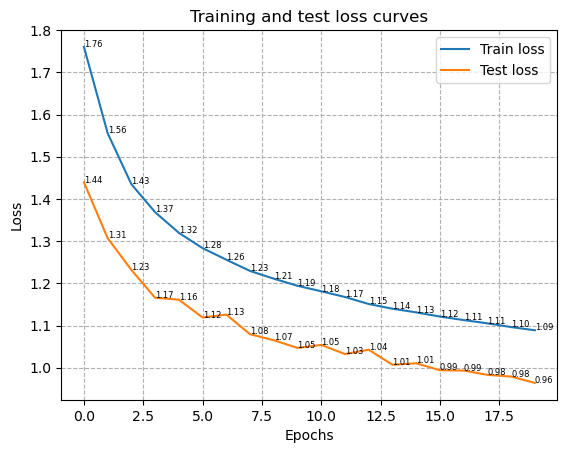

In [61]:
# Plot the loss curves
plt.plot(range(epochs), train_loss, label="Train loss")
plt.plot(range(epochs), test_loss, label="Test loss")
plt.grid(linestyle = '--')
for x,y,p in zip(range(epochs),train_loss, test_loss):
    plt.text(x,y,'%.2f' % y,fontdict={'fontsize':6})
    plt.text(x,p,'%.2f' % p,fontdict={'fontsize':6})
plt.title("Training and test loss curves")
plt.ylabel("Loss")
plt.xlabel("Epochs")
plt.legend()

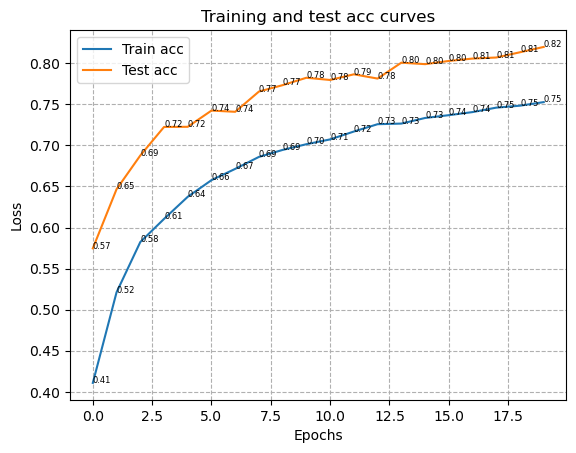

In [63]:
# Plot the acc curves
train_acc_n = [t.cpu().item() for t in train_acc]
test_acc_n = [t.cpu().item() for t in test_acc]

plt.plot(range(epochs), train_acc_n, label="Train acc")
plt.plot(range(epochs), test_acc_n, label="Test acc")
plt.grid(linestyle = '--')
for x,y,p in zip(range(epochs),train_acc_n, test_acc_n):
    plt.text(x,y,'%.2f' % y,fontdict={'fontsize':6})
    plt.text(x,p,'%.2f' % p,fontdict={'fontsize':6})
plt.title("Training and test acc curves")
plt.ylabel("Loss")
plt.xlabel("Epochs")
plt.legend()